## This is an example of Iterative workflow 

In [83]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from typing import TypedDict, Literal, Annotated
import operator
from pydantic import BaseModel, Field
from dotenv import load_dotenv
import json
load_dotenv()

True

In [84]:
class TweetState(TypedDict):
    topic: str
    tweet: str
    evaluation: Literal['approved', 'needs_improvement']
    feedback: str
    iteration: int = 0
    max_iterations: int
    tweet_history: Annotated[list[str], operator.add]
    feedback_history: Annotated[list[str], operator.add]

In [85]:
graph = StateGraph(TweetState)

In [86]:
class EvalSchema(BaseModel):
    evaluation: Literal['approved', 'needs_improvement'] = Field(description="Whether the tweet is good enough or needs improvement")
    feedback: str = Field(description="Constructive feedback for improving the tweet if needed")

In [101]:
generate_model = ChatOpenAI(model='gpt-3.5-turbo')
evaluate_model = ChatOpenAI(model='gpt-5-mini').with_structured_output(EvalSchema)
optimize_model = ChatOpenAI(model='gpt-4o-mini')

In [88]:
def generate_tweet(state: TweetState):
    prompt = f"""Generate a tweet about {state['topic']} and make sure it is catchy and has viral keywords. 
                Limit the tweet to 150 characters."""   
    response = generate_model.invoke(prompt)
    
    return {'tweet': response.content, 'tweet_history': [response.content]}

def evaluate_tweet(state: TweetState):
    prompt = f"""Evaluate the following tweet about {state['topic']} and determine if it is likely to be approved or needs improvement. 
                Tweet: {state['tweet']}
                Provide feedback on what can be improved if it needs improvement."""
    response = evaluate_model.invoke(prompt)
    return {'evaluation': response.evaluation, 'feedback': response.feedback, 'feedback_history': [response.feedback]}

def optimize_tweet(state: TweetState):
    prompt = f"""Optimize the following tweet about {state['topic']} based on the feedback provided.
                Original tweet: {state['tweet']}
                Feedback: {state['feedback']}"""
    response = optimize_model.invoke(prompt)
    iteration = state['iteration'] + 1
    return {'tweet': response.content, 'iteration': iteration, 'tweet_history': [response.content], 'feedback_history': ['feedback_history']}


def validate_tweet(state: TweetState) -> Literal['approve', 'disapprove', 'improve']:
    if state['iteration'] >= state['max_iterations']:
        return 'disapprove'   
    if state['evaluation'] == 'approved':
        return 'approve'
    return 'improve'

In [89]:
graph.add_node('generate', generate_tweet)
graph.add_node('evaluate', evaluate_tweet)
graph.add_node('improve', optimize_tweet)
graph.add_edge(START, 'generate')
graph.add_edge('generate', 'evaluate')
graph.add_conditional_edges('evaluate', validate_tweet, {'approve': END, 'improve': 'improve', 'disapprove': END})
graph.add_edge('improve', 'evaluate')

In [90]:
workflow = graph.compile()

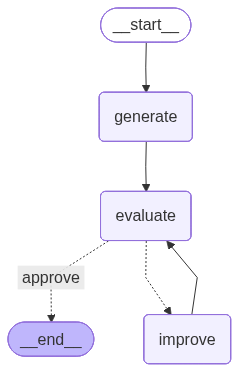

In [91]:
workflow

In [102]:
initial_state = {
    'topic': 'Indian Railways',
    'iteration': 0,
    'max_iterations': 3
}

workflow.invoke(initial_state)

{'topic': 'Indian Railways',
 'tweet': '"From scenic journeys to chaotic stations, Indian Railways never fails to surprise! 🚂🇮🇳 #travel #IncredibleIndia #traintravel"',
 'evaluation': 'approved',
 'feedback': 'Overall this is a lively, shareable tweet — concise, positive and uses relevant hashtags and emojis. Minor improvements you could consider: avoid the potentially negative word “chaotic” (use “bustling” or “bustling stations” instead) if you want a fully promotional tone; add #IndianRailways or a specific route/station name to increase reach and relevance; and attach a strong photo or short video to boost engagement. If you want more engagement, add a question or call-to-action (e.g., “What’s your favorite train journey?”).',
 'iteration': 0,
 'max_iterations': 3,
 'tweet_history': ['"From scenic journeys to chaotic stations, Indian Railways never fails to surprise! 🚂🇮🇳 #travel #IncredibleIndia #traintravel"'],
 'feedback_history': ['Overall this is a lively, shareable tweet — con